Question 1 

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def norm_dist(x, mu, std):
    f = (2*np.pi*(std**2))**-0.5 * (np.exp(-((x - mu)**2)/ (2*std**2)))
    return f

In [17]:
def plot_norm_dist(mu,std):
    x = np.linspace(mu-3*std, mu+3*std, 50)
    y = [norm_dist(x, mu, std) for x in x]
    plt.plot(x,y)

In [19]:
norm_dist(2, 0, 0.2)

3.8472993133532365e-22

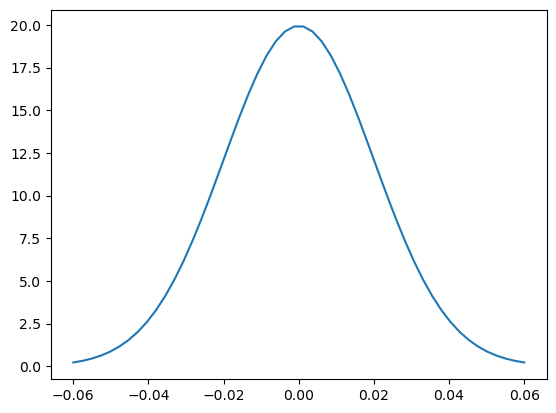

In [23]:
plot_norm_dist(0,(0.02))

1. Conditional probability: suppose that if ω = 1, then y has a normal distribution with
mean 1 and standard deviation σ, and if ω = 2, then y has a normal distribution with
mean 2 and standard deviation σ. Also, suppose Pr(ω = 1) = 0.5 and Pr(ω = 2) = 0.5.
(a) For σ = 2, write the formula for the marginal probability density for y and sketch it.
(b) What is Pr(ω = 1|y = 1), again supposing σ = 2?
(c) Describe how the posterior density of ω changes in shape as σ is increased and as it is
decreased.

In [27]:
p_y = 0.5*norm_dist(1, mu=1, std = 2) + 0.5*norm_dist(x=1, mu = 2, std = 2)
(0.5*norm_dist(1, mu = 1, std = 2)) / p_y

0.5312093733737563

 As σ → ∞, the posterior density for θ approaches the prior (the data contain no information):
Pr(θ = 1|y = 1) → 1
2
. As σ → 0, the posterior density for θ becomes concentrated at 1: Pr(θ =1|y = 1) → 1.


Conditional means and variances: show that (1.8) and (1.9) hold if u is a vector

Chapter 2.

girls born = 241945 
boys born = 251527

p(theta= 0.5)
p(prob girl born > 0.5| y= 241945, n = 241945+ 251527)


p(y|theta>=0.5) / p(y)

What you're working with
Laplace is doing Bayesian inference on a binomial proportion. You have:

A likelihood: each birth is female with probability ω
A prior: ω ~ Uniform(0, 1) — Laplace's "principle of insufficient reason"
Data: y girls out of n total births

The key question to ask yourself first
With a Uniform(0,1) prior and a Binomial likelihood, what is the posterior distribution of ω? There's a well-known conjugate family here — do you know what it is?

The principle of indifference (also called principle of insufficient reason) is a rule for assigning epistemic probabilities. The principle of indifference states that in the absence of any relevant evidence, agents should distribute their credence (or "degrees of belief") equally among all the possible outcomes under consideration.[1] It can be viewed as an application of the principle of parsimony and as a special case of the principle of maximum entropy. In Bayesian probability, this is the simplest non-informative prior.

In mathematics, a monotonic function (or monotone function) is a function between ordered sets that preserves or reverses the given order.[1][2][3] This concept first arose in calculus, and was later generalized to the more abstract setting of order theory.

θ2
θ1
( n C y)ω^^y(1 − ω)^^n-ydω

the maximum at theta= y/n   intuitively, y/n is what we SEE in the data, so would make sense to be the max.

log[ωy(1−ω)n−y]=ylogω+(n−y)log(1−ω)
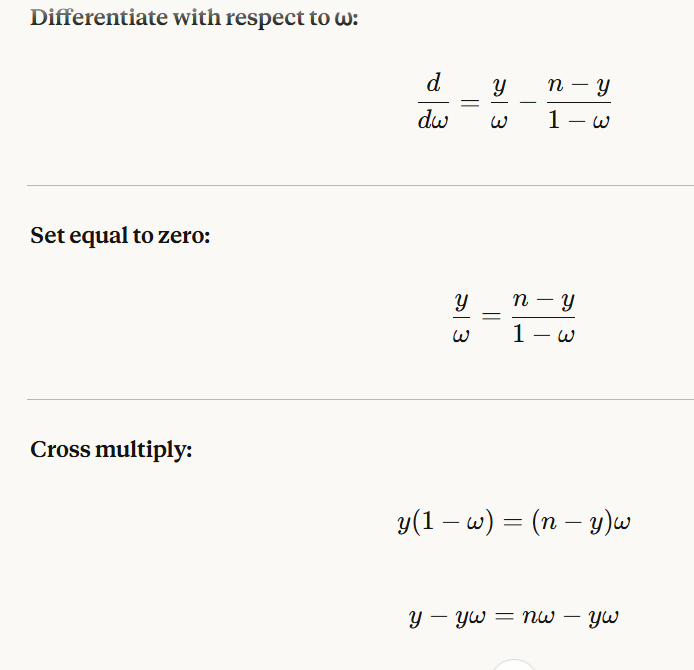

And this ω^=y/n\hat{\omega} = y/n
ω^=y/n is called the
Maximum Likelihood Estimate (MLE) — the value of ω that makes your observed data most probable. It's also just the intuitive "observed proportion" of girls in the data.
Now — shall we move on to the second-order expansion around this point, which is where the normal approximation comes from?


 ωy(1−ω)n−y\omega^y (1-\omega)^{n-y}
ωy(1−ω)n−y 

(y/n)^^y(1-(y/n)^^(n-y)) --> log -----> ylog((y/n) + (n-y)log((1-(y/n))))


In [ ]:
from scipy.stats import binom

def binomialpmf(y, n, theta):

    pmf = binom.pmf(y, n, theta) 
    return pmf

binomialpmf(241945,241945+251527,0.5)

4.474383213900688e-44

In [ ]:
#to find the probability of girls >0.5, is the sum of 


2.2 Posterior as compromise between data and prior information

What Beta(a, b) means intuitively:
Think of a and b as counts of past observations. a = number of successes you've "seen", b = number of failures. So:

Beta(1,1) — 1 success, 1 failure seen → total ignorance, flat line
Beta(3,1) — 3 successes, 1 failure → belief skewed toward ω being high
Beta(10,10) — equal but lots of data → tight peak at 0.5

Every time you observe new data (y girls, n-y boys), you just add to the counts: Beta(1+y, 1+n-y). That's the whole posterior update. Beautifully simple.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import beta

# ── Setup ──────────────────────────────────────────────────────────────────────
N_OBS   = 20
PRIOR_A = 1
PRIOR_B = 1
Y_VALUES = [2, 6, 10, 14, 18]
COLORS   = ["#e63946", "#f69342", "#2a9d8f", "#457b9d", "#9b5de5"]

omega = np.linspace(0.001, 0.999, 500)

prior       = beta(PRIOR_A, PRIOR_B)
prior_mean  = prior.mean()
prior_var   = prior.var()

posteriors = []
for y, col in zip(Y_VALUES, COLORS):
    a, b    = PRIOR_A + y, PRIOR_B + N_OBS - y
    dist    = beta(a, b)
    posteriors.append(dict(y=y, dist=dist, mean=dist.mean(),
                           var=dist.var(), color=col, a=a, b=b))

avg_post_mean  = np.mean([p["mean"] for p in posteriors])
avg_post_var   = np.mean([p["var"]  for p in posteriors])
var_post_means = np.var( [p["mean"] for p in posteriors])

In [21]:
print(prior_mean)
print(prior_var)

0.5
0.08333333333333333


Normal distribution lives on the entire normal line. 

A Beta distribution is a randsom variable, where the variable itself is a probability, so it HAS to be between 0-1.
But here's the subtle bit — the y-axis
For any PDF, the height is not probability. It's probability density. This trips everyone up.
You cannot say "the probability that x = 3.5 is 0.4". The probability of any exact single value is actually zero.
What the height tells you is — probability per unit width. To get actual probability you must integrate over an interval:


A Normal distribution the x axis can be anything



Beta disribution
Beta is a conjugate prior distribution for binomial probability. 
non informative densities, a= b =1

A conjugate prior is a Bayesian statistical concept where the chosen prior distribution and the resulting posterior distribution belong to the same probability distribution family. This mathematical convenience ensures the posterior can be computed analytically without complex numerical integration. Key examples include using a Beta distribution for binomial likelihoods or a Normal distribution for normal likelihoods
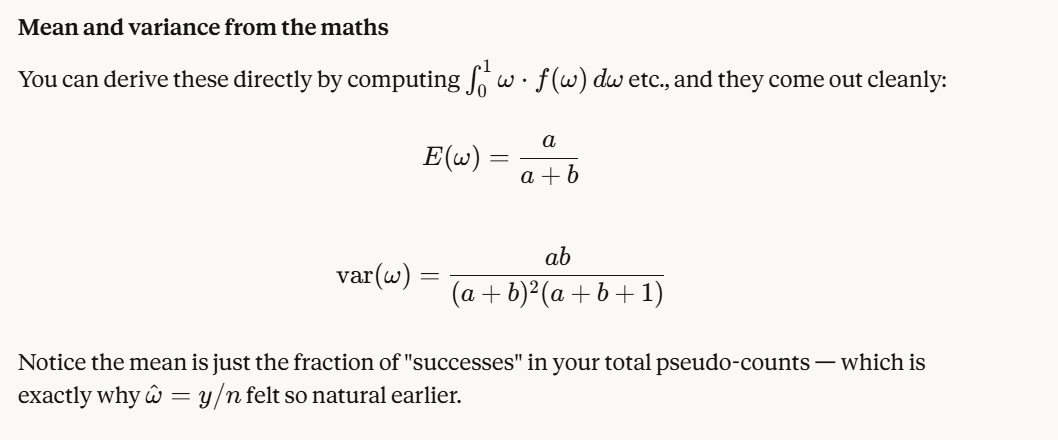

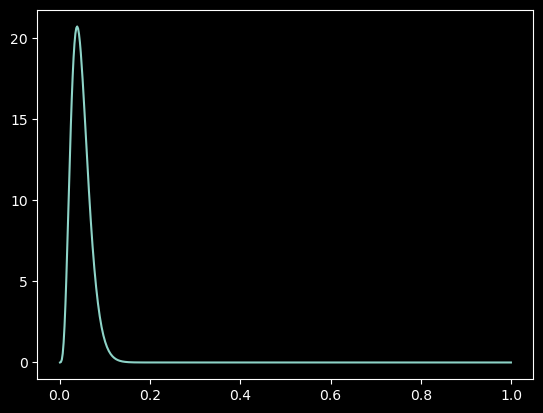

In [37]:
PRIOR_A = 5
PRIOR_B = 100

omega = np.linspace(0.001, 0.999, 500)

prior       = beta(PRIOR_A, PRIOR_B)

plt.plot(omega, [prior.pdf(x) for x in omega])

In [ ]:
# ── Style ──────────────────────────────────────────────────────────────────────
plt.style.use("dark_background")
BG      = "#0d1117"
PANEL   = "#161b22"
BORDER  = "#30363d"
MUTED   = "#8b949e"
WHITE   = "#e6edf3"
GREEN   = "#2a9d8f"
PURPLE  = "#9b5de5"
ORANGE  = "#f4a261"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_title(title, color=MUTED, fontsize=9,
                 loc="left", pad=8, fontfamily="monospace")
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)

In [ ]:
fig = plt.figure(figsize=(13, 16), facecolor=BG)
fig.suptitle("Bayesian Inference  ·  Prior → Posterior",
             fontsize=16, color=WHITE, y=0.98, fontfamily="serif")

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35,
                       left=0.08, right=0.96, top=0.94, bottom=0.04)

# ── 1. Prior ───────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
style_ax(ax1, "PRIOR  ·  p(ω) = Beta(1,1) = Uniform(0,1)")
y_prior = prior.pdf(omega)
ax1.fill_between(omega, y_prior, alpha=0.25, color=GREEN)
ax1.plot(omega, y_prior, color=GREEN, lw=2)
ax1.axvline(prior_mean, color=GREEN, ls="--", lw=1.5,
            label=f"prior mean = {prior_mean:.2f}")
ax1.set_ylim(0, 2.5)
ax1.set_xlabel("ω  (probability of female birth)")
ax1.legend(fontsize=9, framealpha=0, labelcolor=GREEN)
ax1.text(0.5, 0.6,
         f"mean = {prior_mean:.3f}     variance = {prior_var:.4f}",
         transform=ax1.transAxes, ha="center", color=MUTED, fontsize=9)
plt.show()

In [34]:
# ── 3. Eq 2.7 — bar of posterior means ────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
style_ax(ax3, "EQ 2.7  ·  E(ω) = E(E(ω|y))")
means = [p["mean"] for p in posteriors]
cols  = [p["color"] for p in posteriors]
bars  = ax3.bar([f"y={p['y']}" for p in posteriors], means,
                color=cols, alpha=0.8, width=0.6)
ax3.axhline(prior_mean, color=GREEN, ls="--", lw=1.5,
            label=f"prior mean = {prior_mean:.3f}")
ax3.axhline(avg_post_mean, color=WHITE, ls=":", lw=1.5,
            label=f"avg post. mean = {avg_post_mean:.3f}")
ax3.set_ylim(0, 1)
ax3.set_ylabel("Posterior mean")
ax3.legend(fontsize=8, framealpha=0)
ax3.text(0.5, -0.22,
         "avg posterior mean ≈ prior mean  ✓",
         transform=ax3.transAxes, ha="center", color=GREEN, fontsize=8.5)

Text(0.5, -0.22, 'avg posterior mean ≈ prior mean  ✓')

In [35]:

# ── 4. Eq 2.8 — variance decomposition ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
style_ax(ax4, "EQ 2.8  ·  var(ω) = E(var(ω|y)) + var(E(ω|y))")

labels  = ["E(var(ω|y))\navg post. var", "var(E(ω|y))\nvar of means", "Prior var"]
values  = [avg_post_var, var_post_means, prior_var]
bar_col = [PURPLE, ORANGE, GREEN]
x = np.arange(len(labels))
ax4.bar(x, values, color=bar_col, alpha=0.85, width=0.5)
ax4.set_xticks(x)
ax4.set_xticklabels(labels, fontsize=8, color=WHITE)
for xi, v in zip(x, values):
    ax4.text(xi, v + 0.0002, f"{v:.5f}", ha="center", color=WHITE, fontsize=8)
ax4.set_ylabel("Variance")
ax4.text(0.5, -0.28,
         f"{avg_post_var:.5f} + {var_post_means:.5f} = {avg_post_var+var_post_means:.5f}  ≈  {prior_var:.5f}  ✓",
         transform=ax4.transAxes, ha="center", color=MUTED, fontsize=8)

Text(0.5, -0.28, '0.00799 + 0.06612 = 0.07411  ≈  0.08333  ✓')

In [36]:
# ── 5. Stacked variance bar ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, :])
style_ax(ax5, "VARIANCE DECOMPOSITION  ·  prior var split into two pieces")
pct1 = avg_post_var   / prior_var * 100
pct2 = var_post_means / prior_var * 100
ax5.barh(["Prior\nvariance"], [pct1], color=PURPLE, alpha=0.85,
         label=f"E(var(ω|y))  =  {avg_post_var:.5f}  ({pct1:.0f}%  — residual uncertainty)")
ax5.barh(["Prior\nvariance"], [pct2], left=[pct1], color=ORANGE, alpha=0.85,
         label=f"var(E(ω|y)) =  {var_post_means:.5f}  ({pct2:.0f}%  — data moves estimate)")
ax5.set_xlim(0, 105)
ax5.set_xlabel("% of prior variance")
ax5.legend(fontsize=9, framealpha=0, loc="lower right")
ax5.text(pct1/2,        0, f"{pct1:.0f}%", va="center", ha="center",
         color=WHITE, fontsize=11, fontweight="bold")
ax5.text(pct1 + pct2/2, 0, f"{pct2:.0f}%", va="center", ha="center",
         color=WHITE, fontsize=11, fontweight="bold")

plt.show()


In [13]:
prior = beta(PRIOR_A, PRIOR_B)
prior.pdf()

TypeError: rv_continuous_frozen.pdf() missing 1 required positional argument: 'x'